# Generate features using alternative (classical) methods

1. **Readability/accessibility** - SMOG, Flesch-Kincaid, ... 
2. **Grammar** - hunspel spell checker

In [1]:
import readability
import syntok.segmenter as segmenter
from scipy.stats import pearsonr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [2]:
# import nltk
# nltk.download('punkt_tab')

In [3]:
df_c19 = pd.read_csv('../data/c19_final.csv')
df_m17 = pd.read_csv('../data/m17_final.csv')

In [4]:
df_c19['abstract_tokenized'] = df_c19['abstract'].apply(lambda text: '\n\n'.join(
    '\n'.join(' '.join(token.value for token in sentence)
              for sentence in paragraph)
    for paragraph in segmenter.analyze(text)))

df_m17['abstract_tokenized'] = df_m17['abstract'].apply(lambda text: '\n\n'.join(
    '\n'.join(' '.join(token.value for token in sentence)
              for sentence in paragraph)
    for paragraph in segmenter.analyze(text)))

### Readability 

Used measures: Flesch-Kincaid grade level, Simple Measure of Gobbledgook (SMOG), Automated Readability Index (ARI)

All are interpreted as US-grades, i.e. index of 5 indicitaes that kindergarten-level education is required to read the text while 15 indicates university-level education 

In [5]:
df_c19_measures = df_c19['abstract_tokenized'].apply(lambda x: readability.getmeasures(x, lang='en'))
df_m17_measures = df_m17['abstract_tokenized'].apply(lambda x: readability.getmeasures(x, lang='en'))

In [6]:
df_c19_measures

0       {'readability grades': {'Kincaid': 16.60006756...
1       {'readability grades': {'Kincaid': 15.08280141...
2       {'readability grades': {'Kincaid': 15.28588038...
3       {'readability grades': {'Kincaid': 10.10177319...
4       {'readability grades': {'Kincaid': 16.68727272...
                              ...                        
2993    {'readability grades': {'Kincaid': 16.16555522...
2994    {'readability grades': {'Kincaid': 15.65744099...
2995    {'readability grades': {'Kincaid': 12.98559006...
2996    {'readability grades': {'Kincaid': 14.15939345...
2997    {'readability grades': {'Kincaid': 16.21838369...
Name: abstract_tokenized, Length: 2998, dtype: object

In [7]:
kincaid = []
ari = []
smog = []
for row in df_c19_measures:
    kincaid.append(row['readability grades']['Kincaid'])
    ari.append(row['readability grades']['ARI'])
    smog.append(row['readability grades']['SMOGIndex'])
df_c19['Kincaid'] = kincaid
df_c19['ARI'] = ari
df_c19['SMOGIndex'] = smog

In [8]:
kincaid = []
ari = []
smog = []
for row in df_m17_measures:
    kincaid.append(row['readability grades']['Kincaid'])
    ari.append(row['readability grades']['ARI'])
    smog.append(row['readability grades']['SMOGIndex'])
df_m17['Kincaid'] = kincaid
df_m17['ARI'] = ari
df_m17['SMOGIndex'] = smog

In [9]:
df_m17[['accessibility','Kincaid', 'ARI', 'SMOGIndex']]

,accessibility,Kincaid,ARI,SMOGIndex
0,medium,15.071817,18.053004,16.662601
1,medium,15.689136,18.109889,18.491933
2,medium,16.444371,17.139563,17.342743
3,medium,15.556745,17.350022,17.662878
4,medium,18.309500,21.475320,18.491933
...,...,...,...,...
1995,medium,16.692940,21.273614,18.297059
1996,medium,18.966702,24.268780,20.320508
1997,medium,12.283429,12.135957,14.338934
1998,medium,22.003226,25.368710,20.320508


In [10]:
accessibility_mapping = {'low': 0, 'medium': 1, 'high': 2}
df_c19['accessibility_numeric'] = df_c19['accessibility'].map(accessibility_mapping)
df_m17['accessibility_numeric'] = df_m17['accessibility'].map(accessibility_mapping)

### Pearson Corellation Coefficient for SMOGIndex vs accessibility (LLM), and accessibility vs target

In [28]:
correlation, p_value = pearsonr(list(df_c19['SMOGIndex']), list(df_c19['accessibility_numeric']))
print(f"Pearson correlation coefficient for LLM-generated accessibility and SMOGIndex: {correlation}")
print(f"P-value: {p_value}")

Pearson correlation coefficient for LLM-generated accessibility and SMOGIndex: 0.14700895741474282
P-value: 5.968419032946847e-16


In [31]:
print("Dataset CORD-19:")
correlation, p_value = pearsonr(list(df_c19['cited']), list(df_c19['SMOGIndex']))
print(f"Pearson correlation coefficient for non-LLM-generated readability and and cited: {correlation}")
print(f"P-value: {p_value}")

correlation, p_value = pearsonr(list(df_c19['cited']), list(df_c19['accessibility_numeric']))
print(f"Pearson correlation coefficient for LLM-generated accessibility and cited: {correlation}")
print(f"P-value: {p_value}")

Dataset CORD-19:
Pearson correlation coefficient for non-LLM-generated readability and and cited: 0.05211997301486993
P-value: 0.004310099117304594
Pearson correlation coefficient for LLM-generated accessibility and cited: 0.012064841796274883
P-value: 0.509031280014646


In [30]:
print("Dataset M17+:")
correlation, p_value = pearsonr(list(df_m17['evaluation']), list(df_m17['SMOGIndex']))
print(f"Pearson correlation coefficient for non-LLM-generated readability: {correlation}")
print(f"P-value: {p_value}")

correlation, p_value = pearsonr(list(df_m17['evaluation']), list(df_m17['accessibility_numeric']))
print(f"Pearson correlation coefficient for LLM-generated accessibility: {correlation}")
print(f"P-value: {p_value}")

Dataset M17+:
Pearson correlation coefficient for non-LLM-generated accessibility: -0.18189574828676786
P-value: 2.4438138427176304e-16
Pearson correlation coefficient for LLM-generated accessibility: -0.06617561164319222
P-value: 0.0030678238428840368


In [13]:
def plot_dist(df, columns = ('ARI', 'Kincaid', 'SMOGIndex')):
    plt.figure(figsize=(12, 5))

    for i, col in enumerate(columns, 1):
        plt.subplot(1, 3, i)
    
        sns.histplot(df[col], bins=20, kde=True, color='blue', alpha=0.6)
    
        mean_value = df[col].mean()
        plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value:.2f}')
    
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()  
    
    plt.tight_layout()
    plt.show()


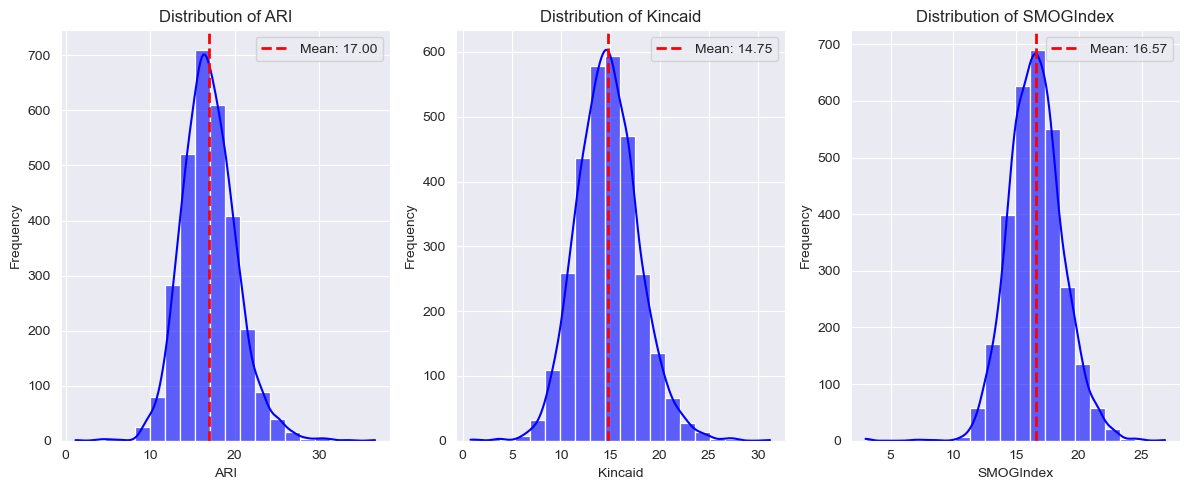

In [14]:
plot_dist(df_c19)

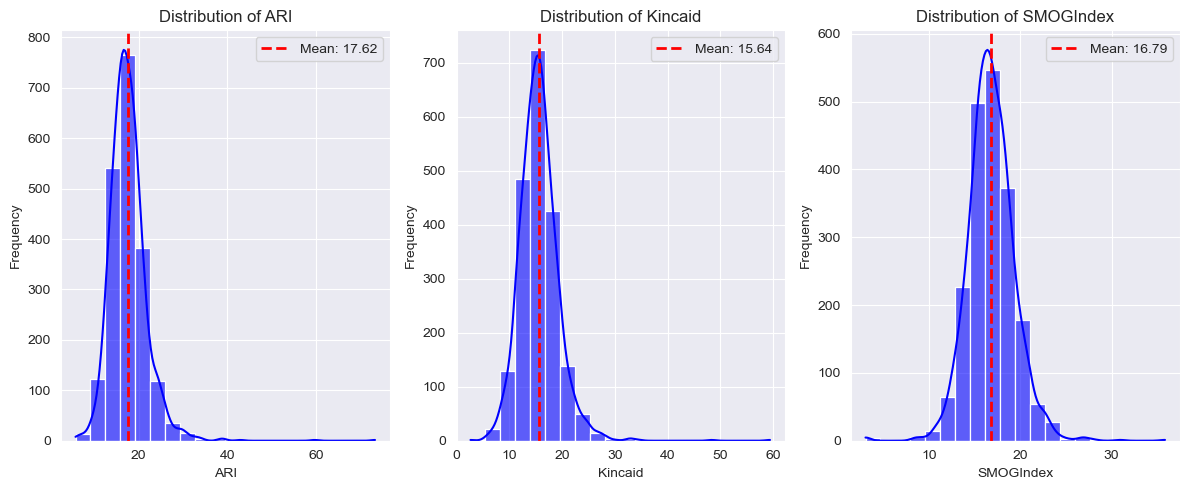

In [15]:
plot_dist(df_m17)

### Grammar

Check grammar using hunspell grammar check, with python inplementation done in spylls library. 

In [16]:
import language_tool_python

tool = language_tool_python.LanguageTool('en')

def has_grammar_error(text):
    matches = tool.check(text)

    return 1 if matches else 0  

df_c19['grammar_ltp'] = df_c19['abstract'].apply(has_grammar_error)
df_m17['grammar_ltp'] = df_m17['abstract'].apply(has_grammar_error)

In [17]:
print(df_c19[['abstract', 'grammar_ltp', 'grammar']].head())
print(df_m17[['abstract', 'grammar_ltp', 'grammar']].head())

                                            abstract  grammar_ltp  grammar
0  Family has resurfaced in many ways as its cont...            0        1
1  Patients who are undocumented immigrants (UIs)...            0        0
2  BACKGROUND: Vaccines are one of the most impor...            0        0
3  Knowledge graph (KG), as a new type of knowled...            0        0
4  The current pandemic of coronavirus disease (C...            1        0
                                            abstract  grammar_ltp  grammar
0  This text depicts the mechanisms that created ...            0        0
1  Translational control targeting the initiation...            0        0
2  Layered elemental materials, such as black pho...            0        1
3  The aim of this book is to unlock the power of...            0        0
4  Theory predicts that higher biodiversity in th...            0        0


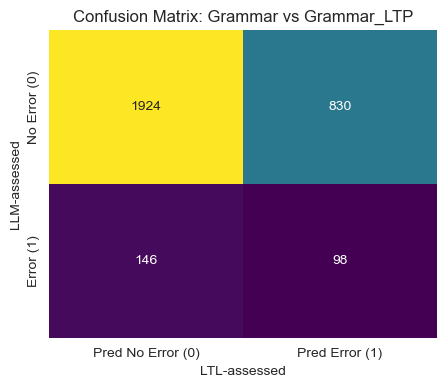

In [18]:
cm = confusion_matrix(df_c19['grammar'], df_c19['grammar_ltp'])
cm_df = pd.DataFrame(cm, index=["No Error (0)", "Error (1)"], columns=["Pred No Error (0)", "Pred Error (1)"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("Confusion Matrix: Grammar vs Grammar_LTP")
plt.ylabel("LLM-assessed")
plt.xlabel("LTL-assessed")
plt.show()

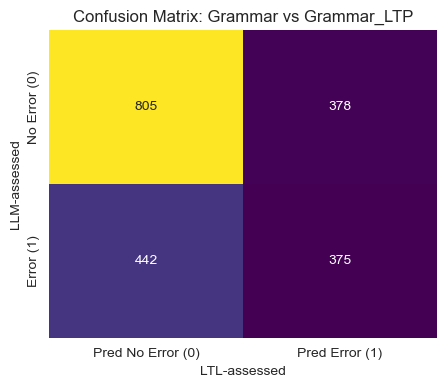

In [19]:
cm = confusion_matrix(df_m17['grammar'], df_m17['grammar_ltp'])
cm_df = pd.DataFrame(cm, index=["No Error (0)", "Error (1)"], columns=["Pred No Error (0)", "Pred Error (1)"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("Confusion Matrix: Grammar vs Grammar_LTP")
plt.ylabel("LLM-assessed")
plt.xlabel("LTL-assessed")
plt.show()


### Pearson Corellation Coefficient for grammar_ltp vs grammar (LLM), and grammar_ltp vs target

In [25]:
correlation, p_value = pearsonr(list(df_c19['grammar']), list(df_c19['grammar_ltp']))
print(f"Pearson correlation coefficient for LLM-generated grammar and LTP-generated grammar: {correlation}")
print(f"P-value: {p_value}")

Pearson correlation coefficient for LLM-generated grammar and LTP-generated grammar: 0.05929845771499975
P-value: 0.0011608373084522655


In [23]:
print("Dataset CORD-19:")
correlation, p_value = pearsonr(list(df_c19['cited']), list(df_c19['grammar_ltp']))
print(f"Pearson correlation coefficient for non-LLM-generated grammar and cited: {correlation}")
print(f"P-value: {p_value}")

correlation, p_value = pearsonr(list(df_c19['cited']), list(df_c19['grammar']))
print(f"Pearson correlation coefficient for LLM-generated grammar and cited: {correlation}")
print(f"P-value: {p_value}")

Dataset CORD-19:
Pearson correlation coefficient for non-LLM-generated grammar and cited: -0.025974269357686805
P-value: 0.15507218147113544
Pearson correlation coefficient for LLM-generated grammar and cited: -0.0024397937505058836
P-value: 0.8937719115644797


In [24]:
print("Dataset M17+:")
correlation, p_value = pearsonr(list(df_m17['evaluation']), list(df_m17['grammar_ltp']))
print(f"Pearson correlation coefficient for non-LLM-generated grammar and evaluation: {correlation}")
print(f"P-value: {p_value}")

correlation, p_value = pearsonr(list(df_m17['evaluation']), list(df_m17['grammar']))
print(f"Pearson correlation coefficient for LLM-generated grammar and evaluation: {correlation}")
print(f"P-value: {p_value}")

Dataset M17+:
Pearson correlation coefficient for non-LLM-generated grammar and evaluation: -0.004378300218901388
P-value: 0.8448590240758171
Pearson correlation coefficient for LLM-generated grammar and evaluation: 0.2179336186453758
P-value: 6.271644675446773e-23
